# AC Countertrend — Optimizer

Buy pullbacks (std below 20-day high) in a bull market (40 EMA > 80 EMA).
Exit on close above `exit_ma`, stop loss, or after `hold_period` days.

Base `hold_period` is 200 and `exit_on_bear` is False so timed/bear exits do not cap upside while testing other parameters.

Optimize one parameter at a time:
- `min_pullback` — entry threshold in standard deviations
- `exit_ma` — sell when close exceeds this SMA period
- `stop_loss_pct` — stop loss below entry (e.g. 0.15 = 15%)
- `hold_period` — maximum days in a trade
- `std_period` — lookback for return volatility (pullback denominator)
- `high_period` — lookback for the high close (pullback numerator)
- `ema_slow` — slow EMA for bull/bear filter (`ema_fast` fixed at 40)

In [61]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

import pinkfish as pf
import strategy

pd.options.display.float_format = '{:0.2f}'.format

%matplotlib inline

In [62]:
plt.rcParams['figure.figsize'] = (10, 7)

Global data

In [63]:
symbol = 'SPY'
capital = 10000
start = datetime.datetime(1900, 1, 1)
#start = datetime.datetime(*pf.SP500_BEGIN)
end = datetime.datetime.now()

Define optimizations (pick one)

In [64]:
optimize_min_pullback = False
optimize_exit_ma = False
optimize_stop_loss_pct = False
optimize_hold_period = False
optimize_std_period = False
optimize_high_period = True
optimize_ema_slow = False

if optimize_min_pullback:
    Xs = [f'{x:.1f}' for x in [i / 2 for i in range(4, 11)]]  # 2.0 .. 5.0
elif optimize_exit_ma:
    Xs = [str(x) for x in range(5, 51, 5)]
elif optimize_stop_loss_pct:
    Xs = [str(x) for x in range(5, 26, 5)]  # percent: 5 .. 25
elif optimize_hold_period:
    Xs = [str(x) for x in range(5, 41, 5)]
elif optimize_std_period:
    Xs = [str(x) for x in range(10, 61, 10)]
elif optimize_high_period:
    Xs = [str(x) for x in range(5, 21, 1)]
elif optimize_ema_slow:
    Xs = [str(x) for x in range(60, 201, 20)]

In [65]:
options = {
    'use_adj': False,
    'use_cache': True,
    'margin': 1,
    'std_period': 40,
    'high_period': 20,
    'ema_fast': 40,
    'ema_slow': 80,
    'hold_period': 200,
    'min_pullback': 3.0,
    'exit_ma': 20,
    'stop_loss_pct': 0.15,
    'exit_on_bear': False,
}

Run strategy

In [66]:
strategies = pd.Series(dtype=object)
for X in Xs:
    print(X, end=' ')
    if optimize_min_pullback:
        options['min_pullback'] = float(X)
    elif optimize_exit_ma:
        options['exit_ma'] = int(X)
    elif optimize_stop_loss_pct:
        options['stop_loss_pct'] = int(X) / 100
    elif optimize_hold_period:
        options['hold_period'] = int(X)
    elif optimize_std_period:
        options['std_period'] = int(X)
    elif optimize_high_period:
        options['high_period'] = int(X)
    elif optimize_ema_slow:
        options['ema_slow'] = int(X)

    strategies[X] = strategy.Strategy(symbol, capital, start, end, options)
    strategies[X].run()

5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 

Summarize results

In [67]:
metrics = ('annual_return_rate',
           'max_closed_out_drawdown',
           'annualized_return_over_max_drawdown',
           'drawdown_recovery_period',
           'expected_shortfall',
           'best_month',
           'worst_month',
           'sharpe_ratio',
           'sortino_ratio',
           'monthly_std',
           'pct_time_in_market',
           'total_num_trades',
           'pct_profitable_trades',
           'avg_points')

df = pf.optimizer_summary(strategies, metrics)
df

,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
annual_return_rate,7.38,7.19,6.94,7.06,7.17,7.08,7.21,6.93,6.94,6.80,6.98,6.93,6.96,6.93,6.84,6.92
max_closed_out_drawdown,-23.83,-24.28,-24.26,-24.26,-24.24,-24.21,-24.29,-24.29,-24.25,-24.21,-24.27,-24.27,-24.25,-24.21,-24.30,-24.27
annualized_return_over_max_drawdown,0.31,0.30,0.29,0.29,0.30,0.29,0.30,0.29,0.29,0.28,0.29,0.29,0.29,0.29,0.28,0.29
drawdown_recovery_period,484.00,537.00,532.00,521.00,521.00,521.00,521.00,521.00,508.00,432.00,427.00,427.00,427.00,427.00,521.00,521.00
expected_shortfall,-5.07,-4.99,-5.01,-4.91,-4.91,-4.91,-4.91,-5.20,-5.11,-5.11,-5.09,-5.09,-5.09,-5.09,-5.11,-5.01
best_month,10.21,10.21,10.19,10.23,11.14,11.16,11.14,11.14,11.15,11.11,11.13,11.15,11.12,11.13,11.15,11.14
worst_month,-23.83,-23.81,-23.78,-23.78,-23.78,-23.75,-23.81,-23.81,-23.78,-23.75,-23.80,-23.79,-23.79,-23.74,-23.83,-23.80
sharpe_ratio,0.68,0.66,0.64,0.65,0.66,0.65,0.66,0.64,0.65,0.63,0.65,0.64,0.65,0.64,0.63,0.64
sortino_ratio,0.58,0.57,0.55,0.56,0.57,0.56,0.57,0.56,0.56,0.55,0.56,0.56,0.56,0.56,0.55,0.56
monthly_std,2.61,2.61,2.61,2.61,2.61,2.62,2.63,2.67,2.67,2.66,2.68,2.68,2.68,2.68,2.69,2.69


Bar graphs

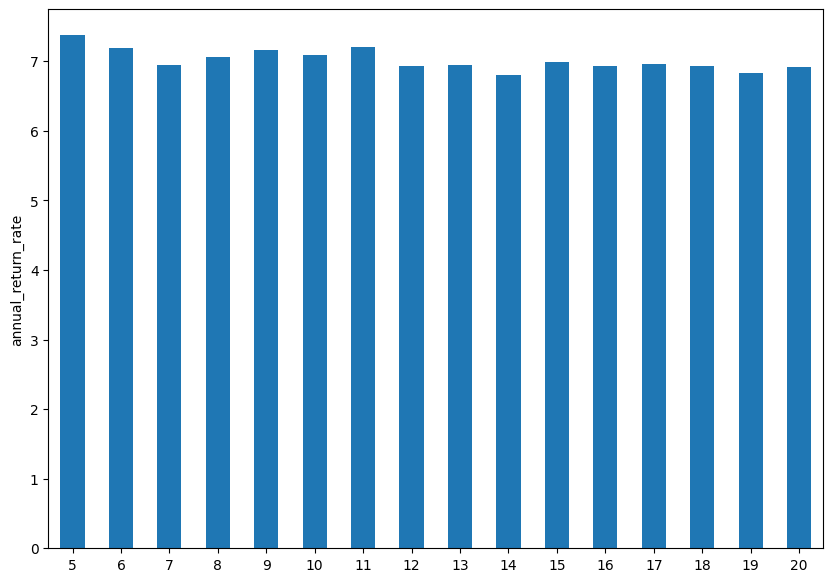

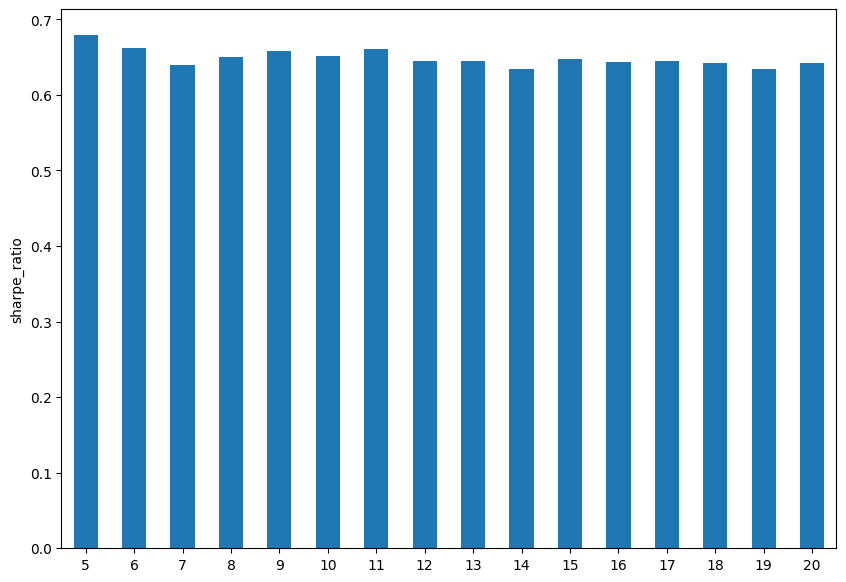

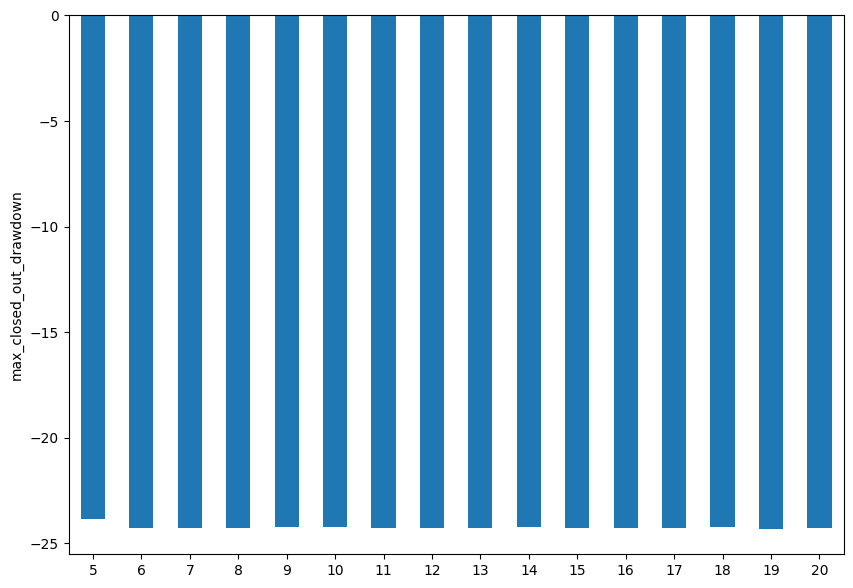

In [68]:
pf.optimizer_plot_bar_graph(df, 'annual_return_rate')
pf.optimizer_plot_bar_graph(df, 'sharpe_ratio')
pf.optimizer_plot_bar_graph(df, 'max_closed_out_drawdown')

Benchmark

In [69]:
s = strategies[Xs[0]]
benchmark = pf.Benchmark(symbol, capital, s.start, s.end)
benchmark.run()

Equity curve (pick a run to plot vs benchmark)

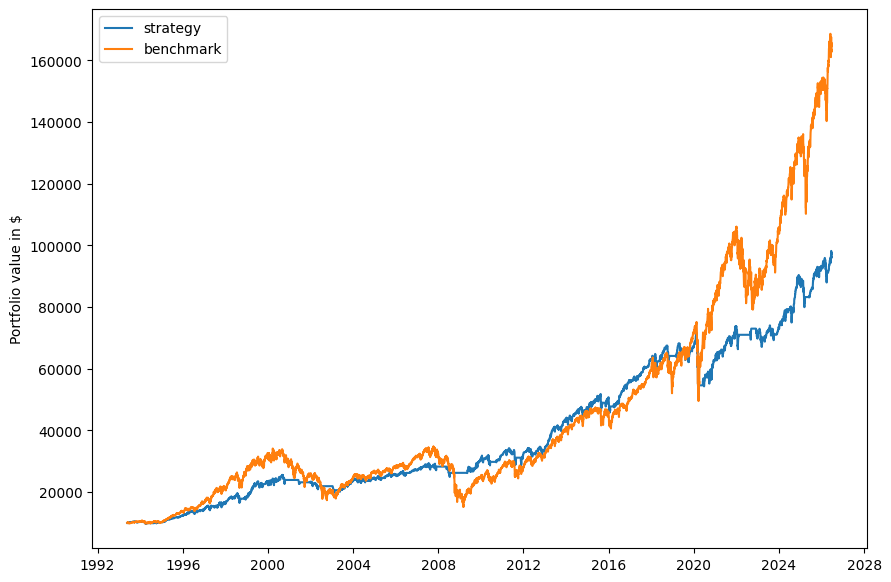

In [73]:
if optimize_min_pullback:
    Y = '3.0'
elif optimize_exit_ma:
    Y = '20'
elif optimize_stop_loss_pct:
    Y = '15'
elif optimize_hold_period:
    Y = '200'
elif optimize_std_period:
    Y = '40'
elif optimize_high_period:
    Y = '10'
elif optimize_ema_slow:
    Y = '80'

pf.plot_equity_curve(strategies[Y].dbal, benchmark=benchmark.dbal)

Compare all parameter values

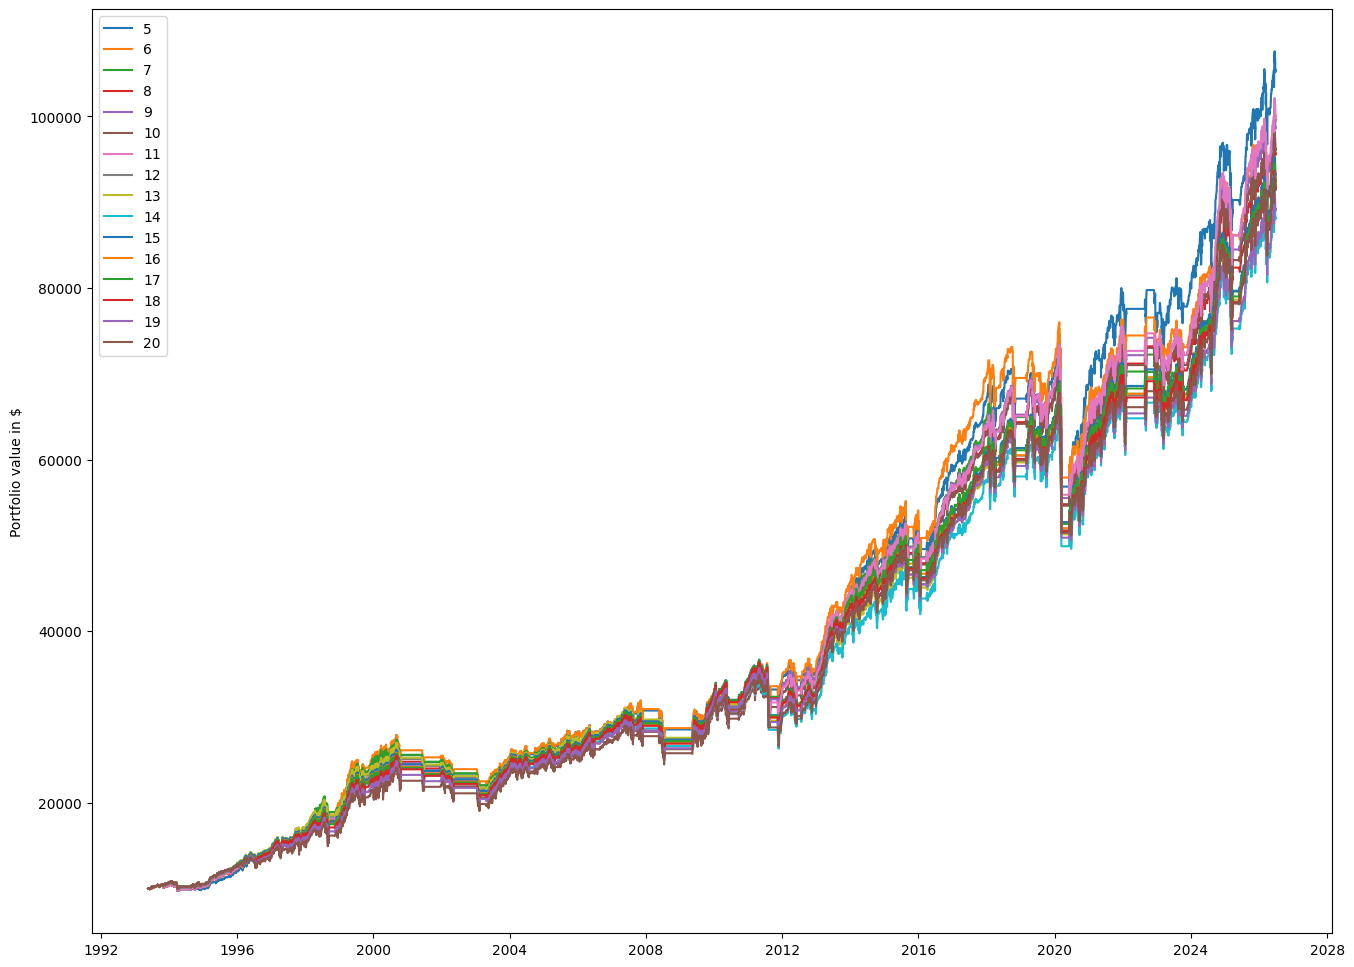

In [71]:
labels = []
for s in strategies:
    if optimize_min_pullback:
        label = s.options['min_pullback']
    elif optimize_exit_ma:
        label = s.options['exit_ma']
    elif optimize_stop_loss_pct:
        label = s.options['stop_loss_pct']
    elif optimize_hold_period:
        label = s.options['hold_period']
    elif optimize_std_period:
        label = s.options['std_period']
    elif optimize_high_period:
        label = s.options['high_period']
    elif optimize_ema_slow:
        label = s.options['ema_slow']
    labels.append(label)

pf.plot_equity_curves(strategies[:], labels)

Compare optimization with baseline defaults

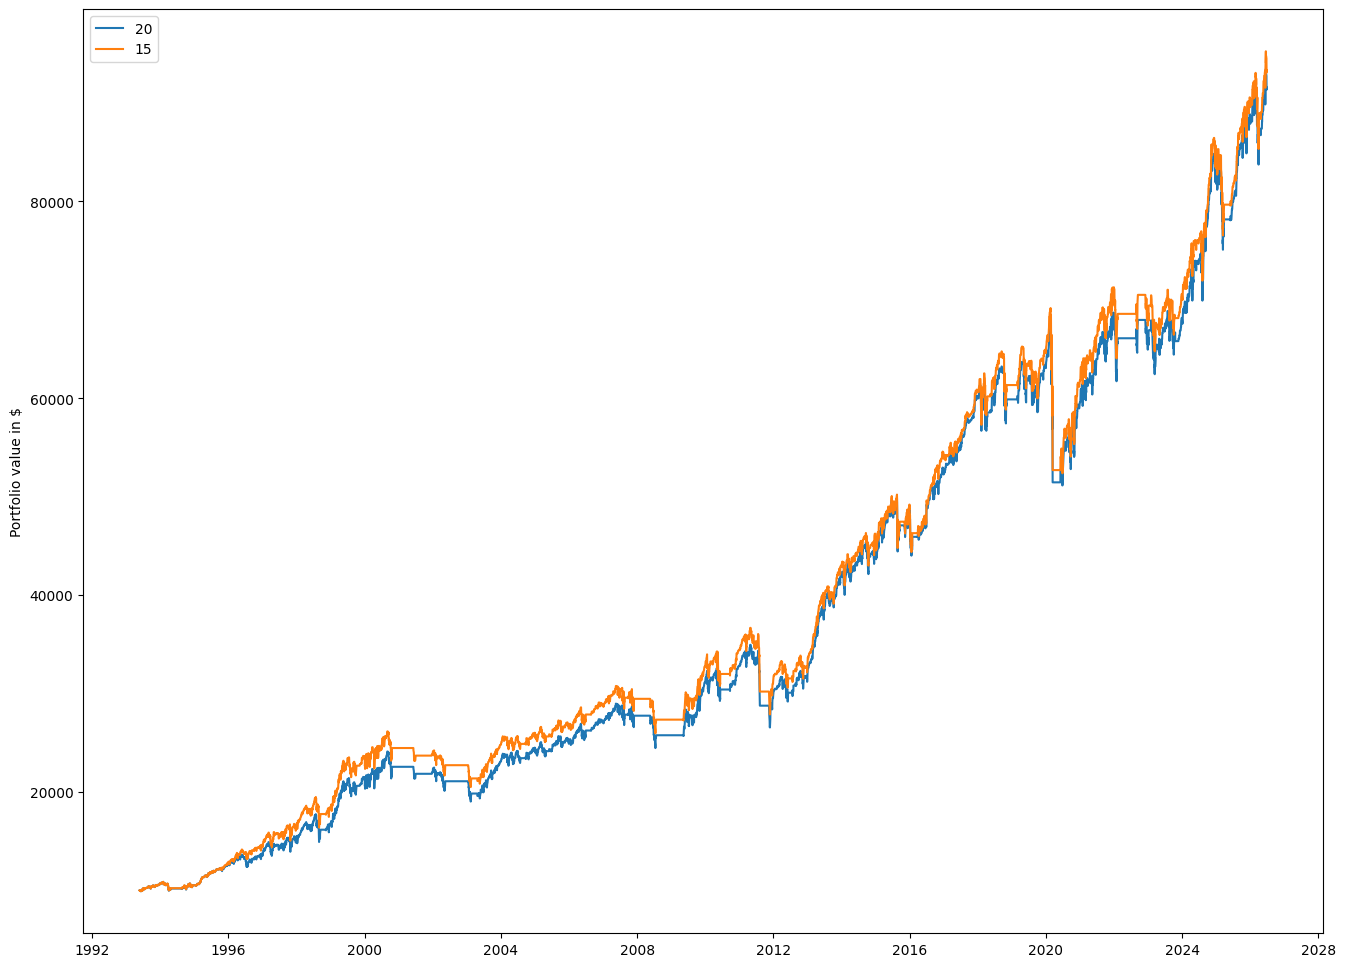

In [72]:
if optimize_min_pullback:
    index = ['3.0', '4.0']
elif optimize_exit_ma:
    index = ['20', '30']
elif optimize_stop_loss_pct:
    index = ['15', '10']
elif optimize_hold_period:
    index = ['20', '10']
elif optimize_std_period:
    index = ['40', '30']
elif optimize_high_period:
    index = ['20', '15']
elif optimize_ema_slow:
    index = ['80', '120']

pf.plot_equity_curves(strategies[index], labels=index)